In [3]:
import pandas as pd

# Read the CSV files into a DataFrame
fake_df = pd.read_csv('../data/raw/Fake.csv')
real_df = pd.read_csv('../data/raw/True.csv')

print(fake_df.head(2))
print(real_df.head(2))

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   


In [4]:
#Add labels
fake_df['label'] = 0
real_df['label'] = 1

# Combine the fake and real DataFrames into a single DataFrame
combined_df = pd.concat([fake_df, real_df], axis=0)

# Shuffle the combined DataFrame
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(combined_df.shape)
print(combined_df.head(2))

(44898, 5)
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   

                date  label  
0  February 13, 2017      0  
1     April 5, 2017       1  


In [5]:
#Understand columns
print(combined_df.columns)
print(combined_df.info())

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None


In [6]:
#Check Class Balance
print(combined_df['label'].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [7]:
#Check for missing values
print(combined_df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [8]:
#Checking for duplicates
print(combined_df.duplicated().sum())

209


In [9]:
#remove duplicates
combined_df = combined_df.drop_duplicates()
print(combined_df.shape)

(44689, 5)


Combine both Title and Text, because with more context then better model performance

In [10]:
combined_df["content"] = combined_df["title"] + " " + combined_df["text"]
print(combined_df["content"].head(2))

0    Ben Stein Calls Out 9th Circuit Court: Committ...
1    Trump drops Steve Bannon from National Securit...
Name: content, dtype: object


Basic Text Exploration

Example: Length of articles

Insight:

Fake news often:
shorter OR more exaggerated
repetitive phrases

In [11]:
combined_df['text_length'] = combined_df['content'].apply(len)
print(combined_df.groupby('label')['text_length'].describe())

         count         mean          std   min      25%     50%     75%  \
label                                                                     
0      23478.0  2642.749936  2533.838628  31.0  1530.25  2259.0  3126.0   
1      21211.0  2443.700627  1684.042483  32.0   971.50  2282.0  3291.5   

           max  
label           
0      51893.0  
1      29849.0  


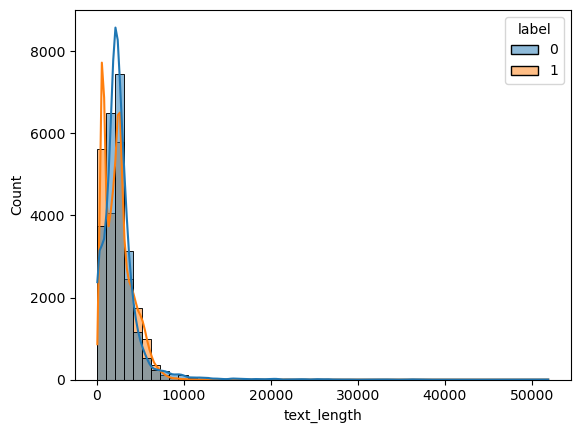

In [12]:
#Quick Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=combined_df, x='text_length', hue='label', bins=50, kde=True)
plt.show()

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)
combined_df.to_csv('../data/processed/combined_data.csv', index=False)

OSError: Cannot save file into a non-existent directory: '..\data\processed'